<a href="https://colab.research.google.com/github/mathispernin/DeepLearningInPracticeMVA/blob/Yani/TP3(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP 3  : Graph Neural Networks Architecture

# TUTORIAL

### Install Pytorch Geometric

To handle graph data, we use the library Pytorch Geometric : https://pytorch-geometric.readthedocs.io/en/latest/

*   If you use _Google Colab_, simply run the following cell to install Pytorch Geometric (**advised**). Make sure you are using the GPU : Edit --> Notebook Setting --> Hardware accelerator --> GPU
*   If you plan using your _own environment_, follow the documentation to install Pytorch Geometric : https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html and skip the following cell.

In [50]:
########## INSTALL TORCH GEOMETRIC ##################
# https://pytorch-geometric.readthedocs.io/en/latest/
#####################################################
import torch


def format_pytorch_version(version):
    return version.split("+")[0]


TORCH_version = torch.__version__
TORCH = format_pytorch_version(TORCH_version)


def format_cuda_version(version):
    return "cu" + version.replace(".", "")


CUDA_version = torch.version.cuda
CUDA = format_cuda_version(CUDA_version)

!pip install torch==2.5.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 # downgrade pytorch
!pip install torch-geometric pyg-lib torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.5.0+cu121.html

Looking in indexes: https://download.pytorch.org/whl/cu121
Looking in links: https://data.pyg.org/whl/torch-2.5.0+cu121.html


### Import required packages

Run the following cell to import all required packages. This cell **must not** be modified.

In [51]:
#####################################################
################## PACKAGES #########################
#####################################################
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
import torch_geometric.nn as graphnn
from sklearn.metrics import f1_score
from torch_geometric.datasets import PPI
from torch_geometric.loader import DataLoader

### Dataset

We use the Protein-Protein Interaction (PPI) network dataset which includes:
- 20 graphs for training
- 2 graphs for validation
- 2 graphs for testing

One graph of the PPI dataset has on average 2372 nodes. Each node has:
- 50 features : positional gene sets / motif gene / immunological signatures ...
- 121 (binary) labels : gene ontology sets (way to classify gene products like proteins).

**This problem aims to predict, for a given PPI graph, the correct nodes' labels**.

**It is a node (multi-label) classification task** (trained using supervised learning, with labels to be predicted for each node).

For your curiosity, more detailed information on the dataset and some applications:
- https://cs.stanford.edu/~jure/pubs/pathways-psb18.pdf
- https://arxiv.org/abs/1707.04638

To understand how a graph data is implemented in Pytorch Geometric, refer to : https://pytorch-geometric.readthedocs.io/en/latest/get_started/introduction.html


In [52]:
### LOAD DATASETS

BATCH_SIZE = 2

# Train Dataset
train_dataset = PPI(root="", split="train")
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
# Val Dataset
val_dataset = PPI(root="", split="val")
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
# Test Dataset
test_dataset = PPI(root="", split="test")
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Number of features and classes
n_features, n_classes = train_dataset[0].x.shape[1], train_dataset[0].y.shape[1]

print("Number of samples in the train dataset: ", len(train_dataset))
print("Number of samples in the val dataset: ", len(test_dataset))
print("Number of samples in the test dataset: ", len(test_dataset))
print("Output of one sample from the train dataset: ", train_dataset[0])
print("Edge_index :")
print(train_dataset[0].edge_index)
print("Number of features per node: ", n_features)
print("Number of classes per node: ", n_classes)

Number of samples in the train dataset:  20
Number of samples in the val dataset:  2
Number of samples in the test dataset:  2
Output of one sample from the train dataset:  Data(x=[1767, 50], edge_index=[2, 32318], y=[1767, 121])
Edge_index :
tensor([[   0,    0,    0,  ..., 1744, 1745, 1749],
        [ 372, 1101,  766,  ..., 1745, 1744, 1739]])
Number of features per node:  50
Number of classes per node:  121


### Define a basic Model

Here we define a very simple Graph Neural Network model which will be used as our baseline. This model consists of three graph convolutional layers (from https://arxiv.org/pdf/1609.02907.pdf). The first two layers computes 256 features, followed by an ELU activation function. The last layer is used for (multi-label) classification task, computing 121 features (for each node).

In [53]:
#####################################################
################## MODEL ############################
#####################################################
class BasicGraphModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.graphconv1 = graphnn.GCNConv(input_size, hidden_size)
        self.graphconv2 = graphnn.GCNConv(hidden_size, hidden_size)
        self.graphconv3 = graphnn.GCNConv(hidden_size, output_size)

        self.elu = nn.ELU()

    def forward(self, x, edge_index):
        x = self.graphconv1(x, edge_index)
        x = self.elu(x)
        x = self.graphconv2(x, edge_index)
        x = self.elu(x)
        x = self.graphconv3(x, edge_index)

        return x

Next function is designed to evaluate the performance of the model, computing the F1-Score

In [54]:
#####################################################
############### TEST FUNCTION #######################
#####################################################
def evaluate(model, device, dataloader):
    score_list_batch = []

    model.eval()
    for i, batch in enumerate(dataloader):
        batch = batch.to(device)
        output = model(batch.x, batch.edge_index)
        predict = np.where(output.detach().cpu().numpy() >= 0, 1, 0)
        score = f1_score(batch.y.cpu().numpy(), predict, average="micro")
        score_list_batch.append(score)

    return np.array(score_list_batch).mean()

Next we construct the function to train the model.

In [55]:
#####################################################
############## TRAIN FUNCTION #######################
#####################################################
def train(model, loss_fcn, device, optimizer, max_epochs, train_dataloader, val_dataloader):
    epoch_list = []
    scores_list = []

    # loop over epochs
    for epoch in range(max_epochs):
        model.train()
        losses = []
        # loop over batches
        for i, train_batch in enumerate(train_dataloader):
            optimizer.zero_grad()
            train_batch_device = train_batch.to(device)
            # logits is the output of the model
            logits = model(train_batch_device.x, train_batch_device.edge_index)
            # compute the loss
            loss = loss_fcn(logits, train_batch_device.y)
            # optimizer step
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        loss_data = np.array(losses).mean()
        print("Epoch {:05d} | Loss: {:.4f}".format(epoch + 1, loss_data))

        if epoch % 5 == 0:
            # evaluate the model on the validation set
            # computes the f1-score (see next function)
            score = evaluate(model, device, val_dataloader)
            print("F1-Score: {:.4f}".format(score))
            scores_list.append(score)
            epoch_list.append(epoch)

    return epoch_list, scores_list

Let's train this model !

In [56]:
### DEVICE GPU OR CPU : will select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nDevice: ", device)

### Max number of epochs
max_epochs = 200

### DEFINE THE MODEL
basic_model = BasicGraphModel(input_size=n_features, hidden_size=256, output_size=n_classes).to(
    device
)

### DEFINE LOSS FUNCTION
loss_fcn = nn.BCEWithLogitsLoss()

### DEFINE OPTIMIZER
optimizer = torch.optim.Adam(basic_model.parameters(), lr=0.005)

### TRAIN THE MODEL
epoch_list, basic_model_scores = train(
    basic_model,
    loss_fcn,
    device,
    optimizer,
    max_epochs,
    train_dataloader,
    val_dataloader,
)


Device:  cuda
Epoch 00001 | Loss: 0.6374
F1-Score: 0.4339
Epoch 00002 | Loss: 0.5822
Epoch 00003 | Loss: 0.5618
Epoch 00004 | Loss: 0.5570
Epoch 00005 | Loss: 0.5515
Epoch 00006 | Loss: 0.5466
F1-Score: 0.4922
Epoch 00007 | Loss: 0.5421
Epoch 00008 | Loss: 0.5375
Epoch 00009 | Loss: 0.5342
Epoch 00010 | Loss: 0.5317
Epoch 00011 | Loss: 0.5290
F1-Score: 0.5287
Epoch 00012 | Loss: 0.5264
Epoch 00013 | Loss: 0.5240
Epoch 00014 | Loss: 0.5217
Epoch 00015 | Loss: 0.5195
Epoch 00016 | Loss: 0.5174
F1-Score: 0.5131
Epoch 00017 | Loss: 0.5150
Epoch 00018 | Loss: 0.5127
Epoch 00019 | Loss: 0.5102
Epoch 00020 | Loss: 0.5078
Epoch 00021 | Loss: 0.5059
F1-Score: 0.5337
Epoch 00022 | Loss: 0.5039
Epoch 00023 | Loss: 0.5020
Epoch 00024 | Loss: 0.5002
Epoch 00025 | Loss: 0.4984
Epoch 00026 | Loss: 0.4964
F1-Score: 0.5438
Epoch 00027 | Loss: 0.4946
Epoch 00028 | Loss: 0.4927
Epoch 00029 | Loss: 0.4911
Epoch 00030 | Loss: 0.4895
Epoch 00031 | Loss: 0.4881
F1-Score: 0.5443
Epoch 00032 | Loss: 0.4865
Ep

Let's evaluate the performance of this basic model

Basic Model : F1-Score on the validation set: 0.6494


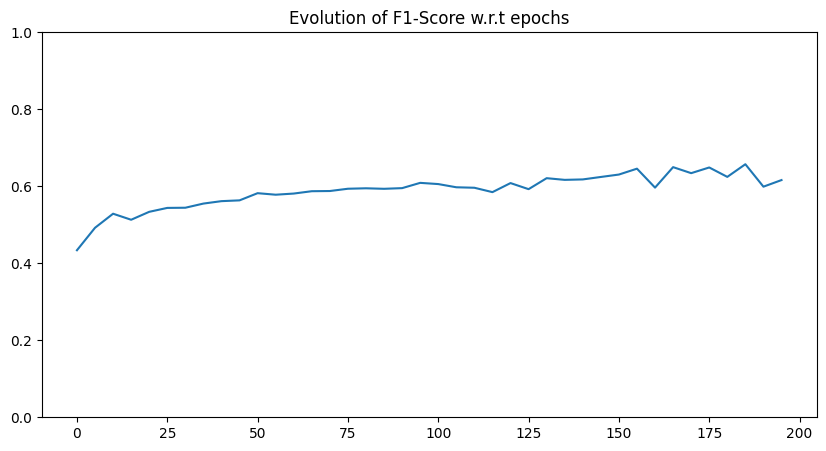

In [57]:
### F1-SCORE ON VALID DATASET
score_valid = evaluate(basic_model, device, val_dataloader)
print("Basic Model : F1-Score on the validation set: {:.4f}".format(score_valid))


### PLOT EVOLUTION OF F1-SCORE W.R.T EPOCHS
def plot_f1_score(epoch_list, scores):
    plt.figure(figsize=[10, 5])
    plt.plot(epoch_list, scores)
    plt.title("Evolution of F1-Score w.r.t epochs")
    plt.ylim([0.0, 1.0])
    plt.show()


plot_f1_score(epoch_list, basic_model_scores)

# QUESTIONS

## Grading

You will be graded on 5 questions. You will need to provide at least 4 files :
1. This Notebook
2. `class_model_gnn.py`
3. `model.pth` (the file **must be of size less than 50Mo** but 20Mo should be enough to get a very good model)
4. `message_passing.py`

If the function you defined passes all the tests, you will get the full grade. Otherwise we  will look at the intermediate questions in the notebook to give you partial credit.



 Please provide clear, short and __bold font__ answers.  

> Question 1 : Design, build and train a model with a F1-score higher than 93% on validation set (**HINT :** https://arxiv.org/pdf/1710.10903.pdf).


 Provide two files : (https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 -  a file  `class_model_gnn.py` containing the class inheriting from `torch.nn.Module` architecture of your final model to load
 -  a `model.pth` file : the model weights

 We will  test your model on final F1-Score on a test set. You must not use the test set for hyperparameter training.

Intermediate question :

 Provide the script for training, and a plot of the training loss.  

In [ ]:
import torch
import torch.nn as nn
import torch_geometric.nn as graphnn

class StudentModel(nn.Module):
    # We hard code the arguments beacuse you want to call the function with no arguments
    def __init__(self, input_size=50, hidden_size=64, output_size=121, heads=4):
        super(StudentModel, self).__init__()

        # TransformerConv supports multi-head attention
        # We used TransformerConv which leverages a similar attention mechanism to standard Graph Attention Networks (GAT) but gives better performance,
        #allowing us to surpass the maximum F1 score of 70% achieved during our initial GAT trials.
        self.conv1 = graphnn.TransformerConv(input_size, hidden_size, heads=heads)
        self.conv2 = graphnn.TransformerConv(hidden_size * heads, hidden_size, heads=heads)
        # concat=False to average heads at the end
        self.conv3 = graphnn.TransformerConv(hidden_size * heads, output_size, heads=1, concat=False)
        self.elu = nn.ELU()

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.elu(x)
        x = self.conv2(x, edge_index)
        x = self.elu(x)
        x = self.conv3(x, edge_index)
        return x

In [59]:
# Same function used before, we just output the losses to be able to plot the training loss as asked
def our_train(model, loss_fcn, device, optimizer, max_epochs, train_dataloader, val_dataloader):
    epoch_list = []
    scores_list = []
    loss_list = []

    # loop over epochs
    for epoch in range(max_epochs):
        model.train()
        losses = []
        # loop over batches
        for i, train_batch in enumerate(train_dataloader):
            optimizer.zero_grad()
            train_batch_device = train_batch.to(device)
            # logits is the output of the model
            logits = model(train_batch_device.x, train_batch_device.edge_index)
            # compute the loss
            loss = loss_fcn(logits, train_batch_device.y)
            # optimizer step
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        loss_data = np.array(losses).mean()
        loss_list.append(loss_data)
        print("Epoch {:05d} | Loss: {:.4f}".format(epoch + 1, loss_data))

        if epoch % 10 == 0:
            # evaluate the model on the validation set
            # computes the f1-score (see next function)
            score = evaluate(model, device, val_dataloader)
            print("F1-Score: {:.4f}".format(score))
            scores_list.append(score)
            epoch_list.append(epoch)

    return epoch_list, scores_list, loss_list

In [60]:
model = StudentModel().to(device)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fcn = nn.BCEWithLogitsLoss()

epoch_list, our_model_scores,loss_list = our_train(
    model,
    loss_fcn,
    device,
    optimizer,
    max_epochs,
    train_dataloader,
    val_dataloader,
)


Epoch 00001 | Loss: 0.6082
F1-Score: 0.3897
Epoch 00002 | Loss: 0.5561
Epoch 00003 | Loss: 0.5367
Epoch 00004 | Loss: 0.5189
Epoch 00005 | Loss: 0.5036
Epoch 00006 | Loss: 0.4871
Epoch 00007 | Loss: 0.4690
Epoch 00008 | Loss: 0.4494
Epoch 00009 | Loss: 0.4306
Epoch 00010 | Loss: 0.4133
Epoch 00011 | Loss: 0.3972
F1-Score: 0.6536
Epoch 00012 | Loss: 0.3815
Epoch 00013 | Loss: 0.3669
Epoch 00014 | Loss: 0.3532
Epoch 00015 | Loss: 0.3401
Epoch 00016 | Loss: 0.3277
Epoch 00017 | Loss: 0.3166
Epoch 00018 | Loss: 0.3058
Epoch 00019 | Loss: 0.2961
Epoch 00020 | Loss: 0.2894
Epoch 00021 | Loss: 0.2823
F1-Score: 0.7605
Epoch 00022 | Loss: 0.2726
Epoch 00023 | Loss: 0.2626
Epoch 00024 | Loss: 0.2546
Epoch 00025 | Loss: 0.2468
Epoch 00026 | Loss: 0.2393
Epoch 00027 | Loss: 0.2326
Epoch 00028 | Loss: 0.2261
Epoch 00029 | Loss: 0.2200
Epoch 00030 | Loss: 0.2142
Epoch 00031 | Loss: 0.2088
F1-Score: 0.8340
Epoch 00032 | Loss: 0.2042
Epoch 00033 | Loss: 0.2000
Epoch 00034 | Loss: 0.1954
Epoch 00035 | 

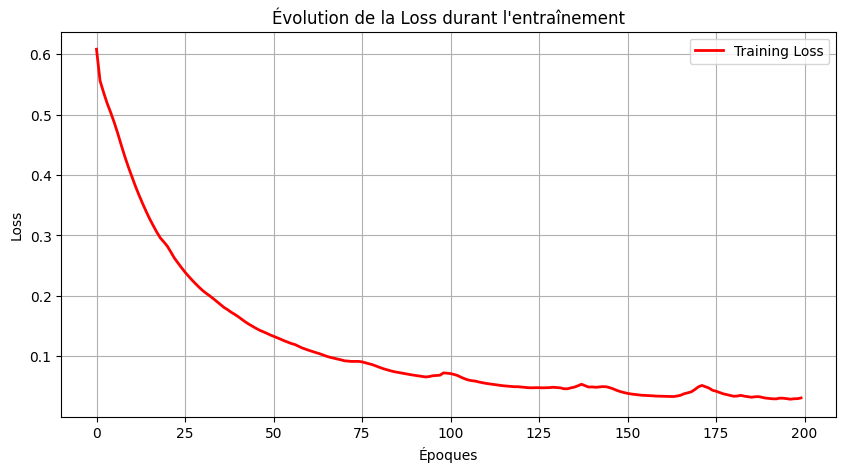

In [61]:
# Plot the loss
plt.figure(figsize=(10, 5))

epochs_total = range(len(loss_list))

plt.plot(epochs_total, loss_list, label='Training Loss', color='red', linewidth=2)
plt.title('Évolution de la Loss durant l\'entraînement')
plt.xlabel('Époques')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Our Model : F1-Score on the validation set: 0.9611


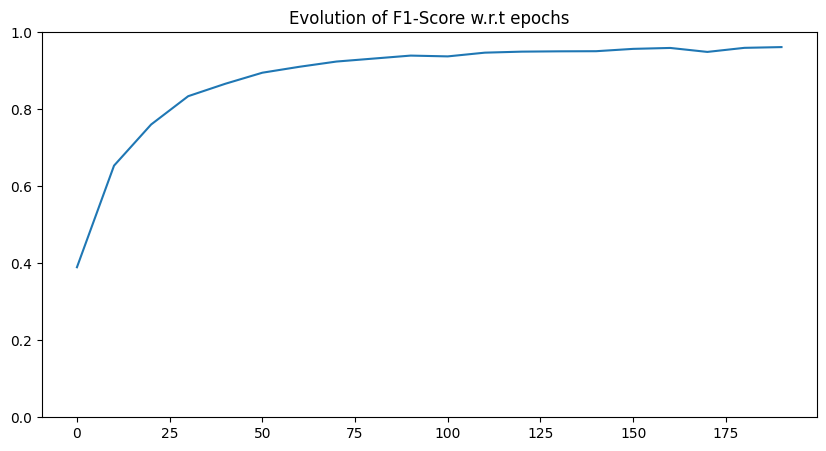

In [62]:
score_valid = evaluate(model, device, val_dataloader)
print("Our Model : F1-Score on the validation set: {:.4f}".format(score_valid))
plot_f1_score(epoch_list, our_model_scores)

In [63]:
## Save the model
torch.save(model.state_dict(), "model.pth")



### This is the part we will run in the inference to grade your model
## Load the model
model = StudentModel()  # !  Important : No argument
model.load_state_dict(torch.load("model.pth", weights_only=True))
model.eval()
print("Model loaded successfully")

Model loaded successfully


## Conv 2D as Message Passing Neural Network


## Introduction

The use of graph is a way to structure data by adding neighborhood information between features. This then allows to do operations on the data that are local to each node and its neighbors. This is the main idea behind Graph Neural Networks (GNNs). [`pytorch-geometric`](https://pytorch-geometric.readthedocs.io/en/latest/) is a library compatible with PyTorch that allows to easily implement GNNs. The most general structure is the [`MessagePassing`](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.MessagePassing.html#torch_geometric.nn.conv.MessagePassing) class that is then used as a base for more specific GNNs as seen in the course ([Graph Convolutional Networks](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GCNConv.html#torch_geometric.nn.conv.GCNConv) or [Graph AttenTion Convolution](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GATConv.html#torch_geometric.nn.conv.GATConv)).

On the other hand, you already know an operation that uses the structure of the data to do local operations: the convolution (https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html). One can see the convolution as a specific case of the message passing neural network. The goal of this notebook is to show how to use the `MessagePassing` class to implement a convolutional neural network.
You will be asked to implement 3 functions. You should give back those three functions in a file named `message_passing.py`. These functions will then be automatically tested. So be sure to respect the function signature and the function name.


## Assumptions

To make the implementation easier we will make some assumptions:
- the input is a single image (batch size of 1) of size 'C x H x W'
- the convolution will be a 5x5 kernel with stride 1 and padding 2.

You may also assume that the Conv2D layer has no bias but it will be slightly penalized in the grading.

Bonus points will be given if you can handle the cases that are not covered by those assumptions.


## Questions

### Question 2

> Using the formalism used in the [`MessagePassing`](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.MessagePassing.html#torch_geometric.nn.conv.MessagePassing) documentation (and on [wikipedia](https://en.wikipedia.org/wiki/Graph_neural_network#Message_passing_layers) with sligthly different notations), explain how theorically you can simulate a 2D convolution using the `MessagePassing` formalism. This may include a pre-processing step to transform the image into a graph and then a post-processing step to transform the graph back into an image. (:warning: Those steps should be independent of the parameters of the convolution, but not necessarily from the hyper-parameters.)

$$\mathbf{x}_{i}^{\prime} = \gamma_{\mathbf{\Theta}}\left( \mathbf{x}_{i},\bigoplus\limits_{j \in \mathcal{N}(i)}\,\phi_{\mathbf{\Theta}}\left( \mathbf{x}_{i},\mathbf{x}_{j},\mathbf{e}_{j,i} \right) \right),$$


HINT : It is possible to do it with the following $\gamma$ :

$$ \gamma_\Theta : x,y \mapsto y $$




**Answer: Simulating 2D Convolution with Message Passing**

To theoretically simulate a 2D convolution using the MessagePassing formalism, we map the grid-structured data of an image to a graph structure and define the message passing functions to replicate the kernel operation.

**1. Pre-processing: Image to Graph**

- To apply a GNN, we first interpret the image tensor (of size $C \times H \times W$) as a graph $\mathcal{G} = (\mathcal{V}, \mathcal{E})$.

- Nodes ($\mathcal{V}$): Every pixel in the image is treated as a node $i$. The total number of nodes is $N = H \times W$.

- Node Features ($\mathbf{x}_i$): The feature vector of node $i$ corresponds to the pixel values at that location across all channels. Thus, $\mathbf{x}_i \in \mathbb{R}^C$.

- Edges ($\mathcal{E}$) & Neighborhood ($\mathcal{N}(i)$): For a kernel of size $K \times K$ (e.g., $5 \times 5$), the neighborhood $\mathcal{N}(i)$ contains all pixels $j$ within the kernel's receptive field centered at $i$. Edges are created from every pixel $j$ in this receptive field to the center pixel $i$.

- Edge Attributes ($\mathbf{e}_{j,i}$): In a CNN, the weight applied to a neighbor depends on its relative position (e.g., top-left, center). We define $\mathbf{e}_{j,i}$ as a unique index $k \in {0, \dots, K^2-1}$ representing the spatial position of neighbor $j$ relative to node $i$.

**2. The Message Passing Steps**

We map the general MPNN equation to the convolution operation:

$$
\mathbf{x}_{i}^{\prime} = \gamma_{\mathbf{\Theta}}\left( \mathbf{x}_{i},\bigoplus\limits_{j \in \mathcal{N}(i)}\,\phi_{\mathbf{\Theta}}\left( \mathbf{x}_{i},\mathbf{x}_{j},\mathbf{e}_{j,i} \right) \right)
$$

The Message Function ($\phi_{\mathbf{\Theta}}$):
The standard convolution computes the product of a specific weight matrix (determined by the neighbor's relative position) and the neighbor's feature vector.
$$
\phi_{\mathbf{\Theta}}\left( \mathbf{x}_{i},\mathbf{x}_{j},\mathbf{e}_{j,i} \right) = \mathbf{W}_{\mathbf{e}_{j,i}} \cdot \mathbf{x}_j
$$
Where:
- $\mathbf{e}_{j,i}$ acts as a selector index for the kernel weights.

- $\mathbf{W}{\mathbf{e}{j,i}}$ is the weight matrix of shape $(C_{out} \times C_{in})$ corresponding to that specific spatial position in the kernel.

**The Aggregation ($\bigoplus$):**
A convolution sums the weighted contributions of all neighbors in the receptive field.
$$
\bigoplus = \sum
$$

**The Update Function ($\gamma_{\mathbf{\Theta}}$)**:
The update function passes the aggregated result as the new node feature. If a bias $\mathbf{b}$ is present, it is added here.
$$
\gamma_{\mathbf{\Theta}}( \mathbf{x}_i, \mathbf{y}_{agg} ) = \mathbf{y}_{agg} + \mathbf{b}
$$
(As per the hint, if we ignore bias, this simplifies to mapping $x, y \mapsto y$).

**3. Post-processing: Graph to Image**

After the message passing step, we obtain a matrix of updated node features $\mathbf{X}'$ of shape $(N, C_{out})$. This matrix is reshaped back into the grid structure $(Batch, C_{out}, H, W)$ to recover the output image format.

In [64]:
import torch
import torch_geometric

### Question 3

> Implement the pre-processing function, you can use the follwing code skeleton (you may change the output type, it is just a strong suggestion):

In [81]:
from torch_geometric.data import Data

def image_to_graph(
    image: torch.Tensor, conv2d: torch.nn.Conv2d | None = None
) -> torch_geometric.data.Data:
    """
    Converts an image tensor to a PyTorch Geometric Data object.

    Arguments:
    ----------
    image : torch.Tensor
        Image tensor of shape (C, H, W).
    conv2d : torch.nn.Conv2d, optional
        Conv2d layer to simulate, by default None
        Is used to determine the size of the receptive field.

    Returns:
    --------
    torch_geometric.data.Data
        Graph representation of the image.
    """
    # Assumptions (remove it for the bonus)
    assert image.dim() == 3, f"Expected 3D tensor, got {image.dim()}D tensor."
    #if conv2d is not None:
        #assert conv2d.padding[0] == conv2d.padding[1] == 2, "Expected padding of 2 on both sides."
        #assert conv2d.kernel_size[0] == conv2d.kernel_size[1] == 5, "Expected kernel size of 5x5."
        #assert conv2d.stride[0] == conv2d.stride[1] == 1, "Expected stride of 1."

    C, H, W = image.shape

    # Setup Kernel parameters
    # If conv2d is provided, we use its params, otherwise default to the assignment assumptions (5x5, pad 2)
    if conv2d is not None:
        k_h, k_w = conv2d.kernel_size
        pad_h, pad_w = conv2d.padding
    else:
        k_h, k_w = 5, 5
        pad_h, pad_w = 2, 2

    # Node Features (x)
    # Permute to (H, W, C) so flattening preserves row-major order (pixel 0 is at (0,0); pixel 1 is at (0,1)...)
    x = image.permute(1, 2, 0).view(-1, C)

    # Edges (edge_index) and Attributes (edge_attr)
    # We iterate over every possible relative position in the kernel (e.g., -2 to +2).
    # For each relative position, we find all valid pixel pairs (source -> target).

    sources = []
    targets = []
    edge_attrs = []

    # Create a grid of node indices corresponding to the image (H, W)
    node_grid = torch.arange(H * W, device=image.device).view(H, W)

    # Iterate over kernel height (dy) and width (dx)
    # dy corresponds to row offset, dx to column offset
    # The kernel covers [-pad, ..., +pad] relative to center
    # We map relative offsets to kernel indices 0..K^2-1
    for dy_idx in range(k_h):
        for dx_idx in range(k_w):
            # Calculate the relative offset (e.g., -2 for index 0 in a 5x5)
            dy = dy_idx - pad_h
            dx = dx_idx - pad_w

            # Calculate the kernel weight index for this position (flat index)
            # This will be our edge attribute
            k_idx = dy_idx * k_w + dx_idx

            # Define the range of valid "Center" (Target) pixels (y, x)
            # A center pixel at y is valid for offset dy if its neighbor (y+dy) is inside [0, H).
            # So: 0 <= y < H  AND  0 <= y + dy < H
            # Implies: max(0, -dy) <= y < min(H, H - dy)
            y_start, y_end = max(0, -dy), min(H, H - dy)
            x_start, x_end = max(0, -dx), min(W, W - dx)

            # If the intersection is empty (e.g. image too small for kernel), skip
            if y_start >= y_end or x_start >= x_end:
                continue

            # TARGETS: The pixels currently being updated (the centers)
            target_indices = node_grid[y_start:y_end, x_start:x_end].flatten()

            # SOURCES: The neighbor pixels
            # They are shifted by (dy, dx) relative to the targets
            source_indices = node_grid[y_start+dy : y_end+dy, x_start+dx : x_end+dx].flatten()

            sources.append(source_indices)
            targets.append(target_indices)

            # ATTRIBUTES: The kernel index (k_idx) repeated for all these edges
            # We use a 1D tensor of Long type
            attr = torch.full((source_indices.size(0),), k_idx, dtype=torch.long, device=image.device)
            edge_attrs.append(attr)

    # Aggregate results
    if sources:
        # edge_index shape: (2, Num_Edges)
        edge_index = torch.stack([torch.cat(sources), torch.cat(targets)], dim=0)
        # edge_attr shape: (Num_Edges, )
        edge_attr = torch.cat(edge_attrs)
    else:
        # Handle empty case
        edge_index = torch.empty((2, 0), dtype=torch.long, device=image.device)
        edge_attr = torch.empty((0,), dtype=torch.long, device=image.device)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

### Question 4

> Implement the post-processing function, you can use the follwing code skeleton:

In [82]:
def graph_to_image(
    data: torch.Tensor, height: int, width: int, conv2d: torch.nn.Conv2d | None = None
) -> torch.Tensor:
    """
    Converts a graph representation of an image to an image tensor.

    Arguments:
    ----------
    data : torch.Tensor
        Graph data representation of the image.
    height : int
        Height of the image.
    width : int
        Width of the image.
    conv2d : torch.nn.Conv2d, optional
        Conv2d layer to simulate, by default None

    Returns:
    --------
    torch.Tensor
        Image tensor of shape (C, H, W).
    """
    # Assumptions (remove it for the bonus)
    assert data.dim() == 2, f"Expected 2D tensor, got {data.dim()}D tensor."
    #if conv2d is not None:
        #assert conv2d.padding[0] == conv2d.padding[1] == 2, "Expected padding of 2 on both sides."
        #assert conv2d.kernel_size[0] == conv2d.kernel_size[1] == 5, "Expected kernel size of 5x5."
        #assert conv2d.stride[0] == conv2d.stride[1] == 1, "Expected stride of 1."

    # Verify consistency
    # data is of shape (Num_Nodes, Channels)
    num_nodes, channels = data.shape

    if num_nodes != height * width:
        raise ValueError(
            f"Number of nodes in data ({num_nodes}) does not match "
            f"requested image dimensions ({height}x{width} = {height * width})."
        )

    # Reshape to Spatial Grid
    # We view the data as (H, W, C).
    # This works because image_to_graph flattened the image in row-major order.
    image_hwc = data.contiguous().view(height, width, channels)

    # Permute to PyTorch format (C, H, W)
    image_chw = image_hwc.permute(2, 0, 1)

    return image_chw

#### Recommended test cases

We **encourage** you to test that you have the property that the pre-processing function followed by the post-processing function is the identity function.

In [85]:
ref_conv = torch.nn.Conv2d(5, 7, kernel_size=5, padding=2, stride=1)
image = torch.randn(5, 10, 11)
g_image = image_to_graph(image, ref_conv)
reconstructed_image = graph_to_image(g_image.x, 10, 11, ref_conv)
assert torch.allclose(image, reconstructed_image)

### Question 5

> Implement the `Conv2dMessagePassing` class that will simulate a 2D convolution using the `MessagePassing` formalism.
You should inherit from the `MessagePassing` class and only change the `__init__` and `message` functions (the `forward` function has already been changed for you). You should use the following code skeleton:

In [86]:
import torch
import torch_geometric

class Conv2dMessagePassing(torch_geometric.nn.MessagePassing):
    """
    A Message Passing layer that simulates a given Conv2d layer.
    """

    def __init__(self, conv2d: torch.nn.Conv2d):
        # We use 'add' aggregation because convolution sums the weighted neighbors.
        super().__init__(aggr='add')

        # Store Convolution Parameters
        # The weights in Conv2d are of shape (Out, In, H, W).
        # We need to access them based on the 'edge_attr', which is the kernel index k (0 to 24).
        # We reshape the weights to (H*W, Out, In) so we can index the first dimension with edge_attr.
        weight = conv2d.weight
        # Flatten spatial dims: (Out, In, K*K) -> Permute: (K*K, Out, In)
        self.kernel_weights = weight.flatten(2).permute(2, 0, 1).contiguous()

        # Store bias (to handle the bonus point / penalty condition)
        self.bias = conv2d.bias

    def forward(self, data):
        self.edge_index = data.edge_index

        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        out = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        return out

    def message(self, x_j: torch.Tensor, edge_attr: torch.Tensor) -> torch.Tensor:
        """
        Computes the message to be passed for each edge.

        Arguments:
        ----------
        x_j : torch.Tensor
            The features of the source node for each edge (of size E x in_channels).
        edge_attr : torch.Tensor
            The attributes of the edge (of size E x 1 or E,).
            Contains the kernel index (0..24) for each edge.

        Returns:
        --------
        torch.Tensor
            The message to be passed for each edge (of size E x out_channels)
        """
        # Select the correct weight matrix for each edge
        # self.kernel_weights shape: (K*K, Out, In)
        # edge_attr shape: (E,)
        # specific_weights shape: (E, Out, In)
        specific_weights = self.kernel_weights[edge_attr]

        # Perform Matrix Multiplication: W * x
        # specific_weights: (E, Out, In)
        # x_j: (E, In)
        # We want (E, Out). We can use torch.einsum for clear batch multiplication.
        # 'eoi' = edge, out, in
        # 'ei'  = edge, in
        # 'eo' = edge, out
        return torch.einsum('eoi,ei->eo', specific_weights, x_j)

    def update(self, aggr_out: torch.Tensor) -> torch.Tensor:
        """
        Updates node embeddings after aggregation.
        This is where the Bias is added (gamma function).
        """
        if self.bias is not None:
            return aggr_out + self.bias
        return aggr_out


## Test example

In [87]:
from message_passing import image_to_graph, graph_to_image, Conv2dMessagePassing

c = 5
h = 10
w = 11

ref_conv = torch.nn.Conv2d(c, 2, kernel_size=5, padding=2, stride=1, bias=False)
image = torch.randn(c, h, w)
g_image = image_to_graph(image, ref_conv)
ref_conv.weight.data = torch.randn_like(ref_conv.weight.data)

conv_mp = Conv2dMessagePassing(ref_conv)
g_image = conv_mp(g_image)

y_th = ref_conv(image)

ref_conv.weight.data = torch.randn_like(ref_conv.weight.data)
reconstructed_image = graph_to_image(g_image, h, w, ref_conv)

assert torch.allclose(y_th, reconstructed_image, atol=1e-4)
